## Synthetic User Population Visualization

Generate a synthetic population of latent trait vectors with `generate_user_population()`, inspect it as a DataFrame, and visualize the two-dimensional latent space.

In [5]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = Path(r"C:\Users\49160\Adaptive-Onboarding")
sys.path.append(str(repo_root))

from src.synthetic import generate_user_population, sample_theta_true
from src.plots import apply_notebook_style, PALETTE

apply_notebook_style()

print(f"Using repo root: {repo_root}")

Using repo root: C:\Users\49160\Adaptive-Onboarding


### Generate Users

In [6]:
n_users = 100
dim = 2
target_mean = np.array([0.0, 0.0])
target_covariance = np.array([
    [1.0, 0.45],
    [0.45, 1.25],
])

theta = generate_user_population(
    n_users=n_users,
    dim=dim,
    mean=target_mean,
    covariance=target_covariance,
    rng_seed=42,
)

user_df = pd.DataFrame(theta, columns=["theta_1", "theta_2"])
user_df.insert(0, "user_id", [f"user_{i:03d}" for i in range(n_users)])

user_df.head()

,user_id,theta_1,theta_2
0,user_000,0.438941,-0.816569
1,user_001,-1.180385,-0.292173
2,user_002,2.330583,1.320691
3,user_003,0.106614,-0.283646
4,user_004,0.563706,-0.401837


### Latent Trait Scatter

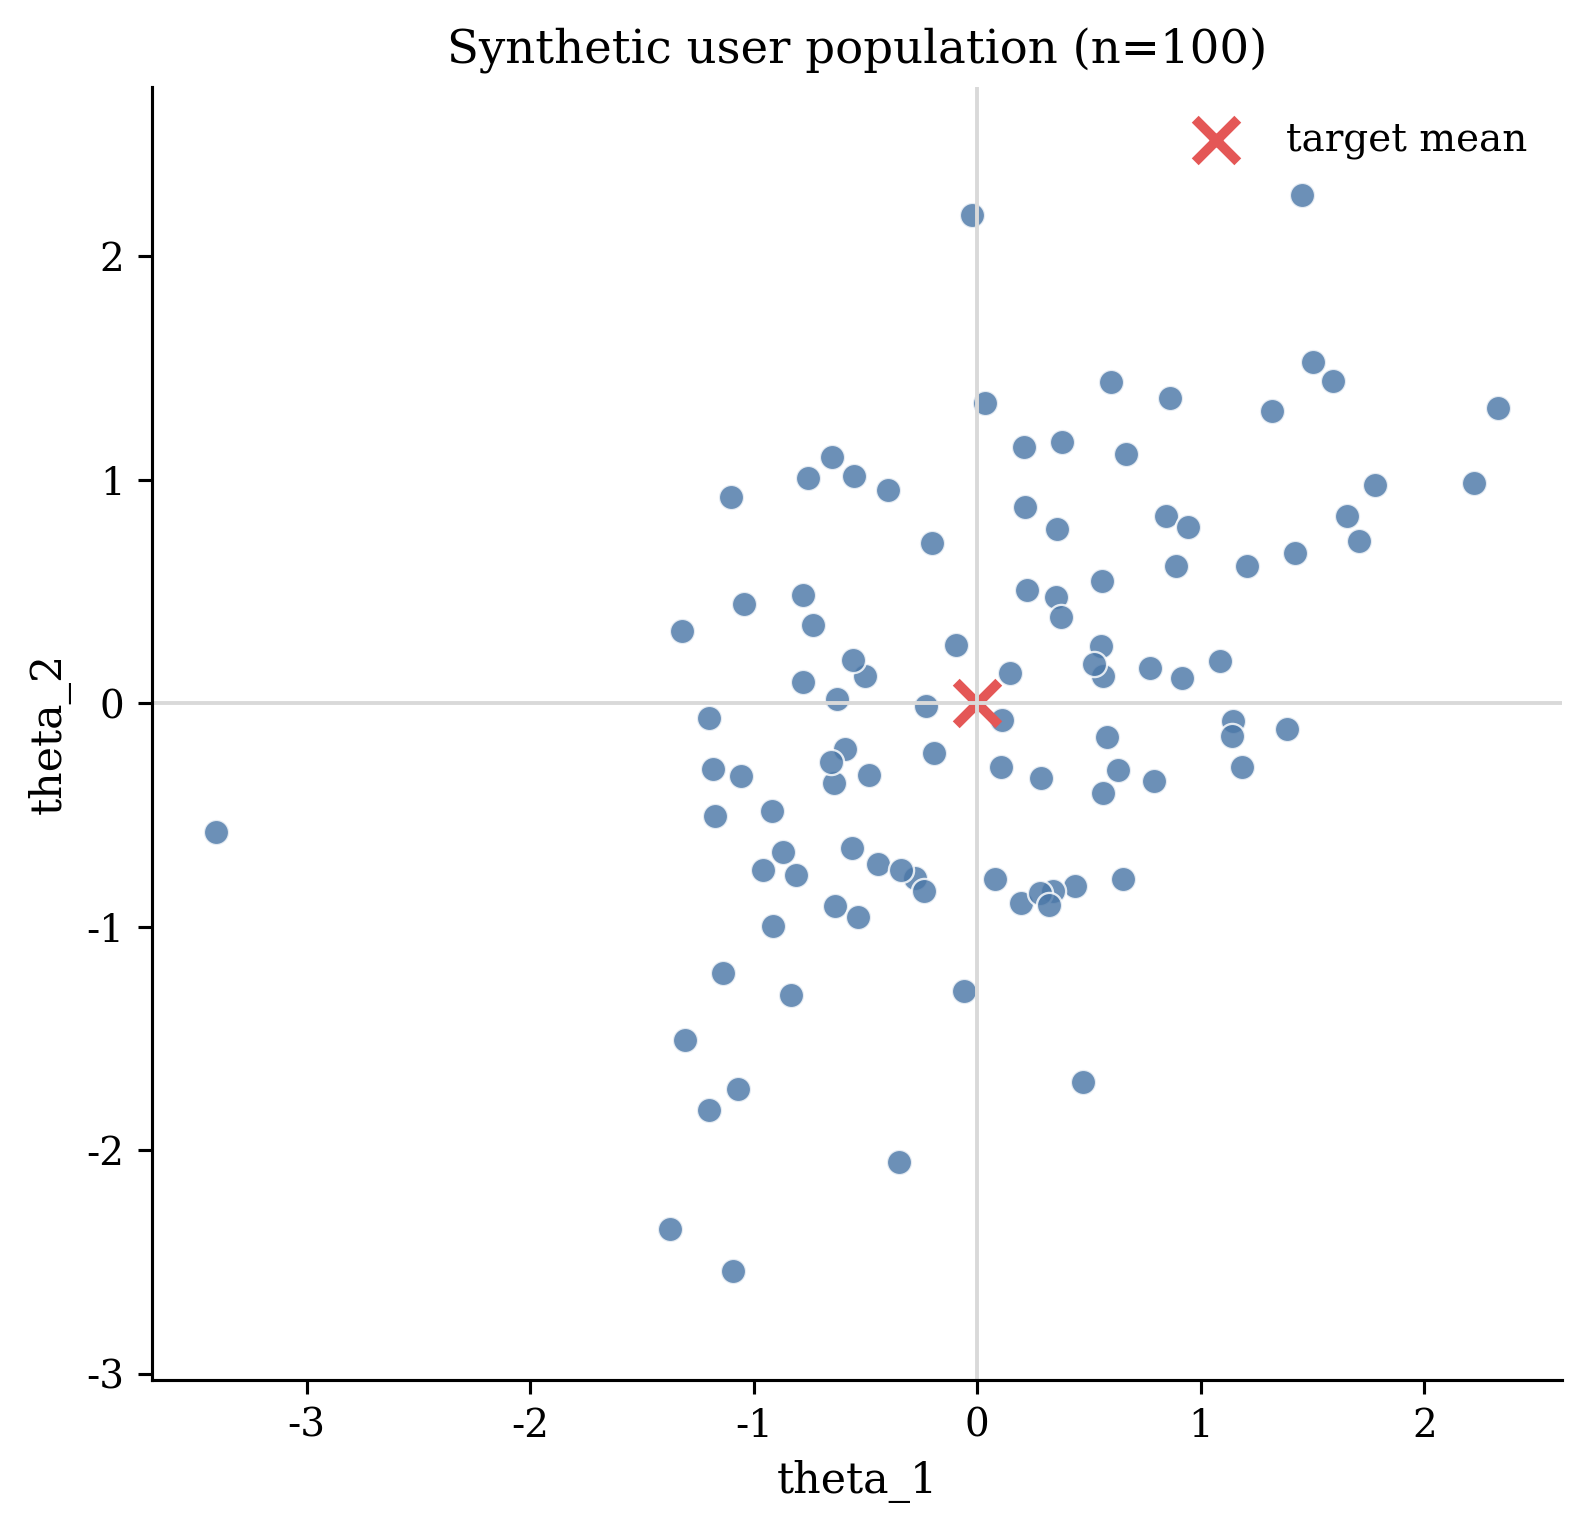

In [7]:
fig, ax = plt.subplots(figsize=(6.5, 6.0))

ax.scatter(
    user_df["theta_1"],
    user_df["theta_2"],
    s=42,
    color=PALETTE["blue"],
    alpha=0.75,
    edgecolor="white",
    linewidth=0.6,
)

ax.scatter(
    target_mean[0],
    target_mean[1],
    s=120,
    color=PALETTE["red"],
    marker="x",
    linewidth=2.5,
    label="target mean",
    zorder=5,
)

ax.axhline(0, color=PALETTE["rule"], linewidth=0.9, zorder=0)
ax.axvline(0, color=PALETTE["rule"], linewidth=0.9, zorder=0)
ax.set_xlabel(r"$\theta_1$")
ax.set_ylabel(r"$\theta_2$")
ax.set_title(f"Synthetic user population (n={n_users})")
ax.set_aspect("equal", adjustable="datalim")
ax.legend()
ax.grid(False)
plt.show()

### Marginals and Summary Checks

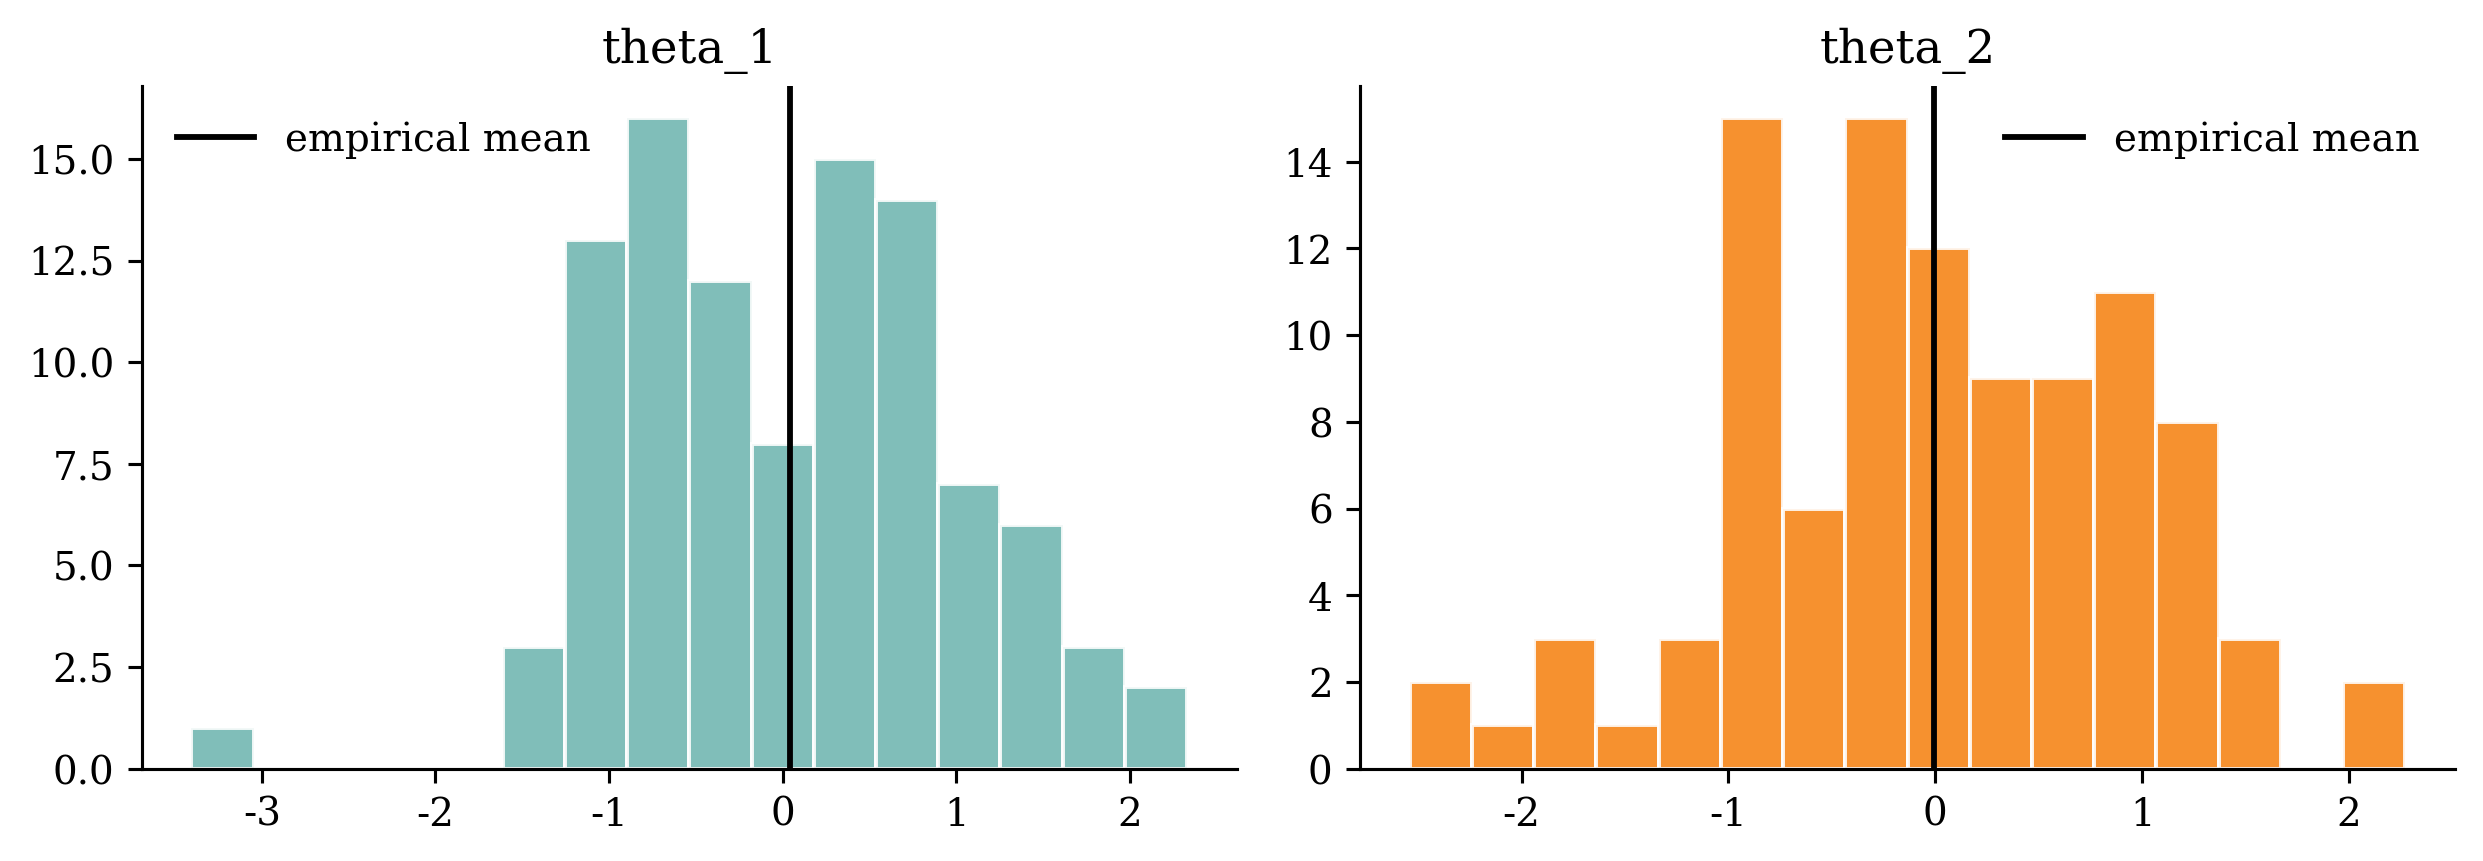

Target mean:
[0. 0.]

Empirical mean:
[ 0.041 -0.008]

Target covariance:
[[1.   0.45]
 [0.45 1.25]]

Empirical covariance:
[[0.911 0.441]
 [0.441 0.895]]


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))

for ax, column, color in zip(axes, ["theta_1", "theta_2"], [PALETTE["teal"], PALETTE["amber"]]):
    ax.hist(user_df[column], bins=16, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(user_df[column].mean(), color=PALETTE["ink"], linewidth=1.5, linestyle="--", label="empirical mean")
    ax.set_title(rf"$\{column}$")
    ax.legend()

plt.tight_layout()
plt.show()

empirical_mean = user_df[["theta_1", "theta_2"]].mean().to_numpy()
empirical_covariance = user_df[["theta_1", "theta_2"]].cov().to_numpy()

print("Target mean:")
print(target_mean)
print("\nEmpirical mean:")
print(np.round(empirical_mean, 3))
print("\nTarget covariance:")
print(target_covariance)
print("\nEmpirical covariance:")
print(np.round(empirical_covariance, 3))

### One User Wrapper

In [9]:
theta_true = sample_theta_true(
    dim=2,
    mean=target_mean,
    covariance=target_covariance,
    rng_seed=7,
)

theta_true

array([-0.19386282,  0.14540272])